# How to Visualize Data in Python

## Learning Objectives
When exploring data, one of the most important things we can do is visualize it so we can better understand it. Like the popular saying "*A picture is worth a thousand words*”, visualizations are sometimes more useful than summary statistics in helping us understand our data. This is because visualizations are a great tool for asking and answering questions about data. Depending on the type of question we are trying to answer, there are four major types of visualizations we could use. They are relationship, distribution, comparison and composition. By the end of this tutorial, you will have learned: 

+ how to create a relationship visualization
+ how to create a distribution visualization
+ how to create a comparison visualization
+ how to create a composition visualization

In [1]:
%matplotlib inline

Let's import and preview the data we will use to illustrate how to visualize data.

In [2]:
import pandas as pd
vehicles = pd.read_csv("vehicles.csv")
vehicles.head()

,citympg,cylinders,displacement,drive,highwaympg,make,model,class,year,transmissiontype,transmissionspeeds,co2emissions
0,14.0,6,4.1,2-Wheel Drive,19.0,Buick,Electra/Park Avenue,Large Cars,1984,Automatic,4,555.437500
1,14.0,8,5.0,2-Wheel Drive,20.0,Buick,Electra/Park Avenue,Large Cars,1984,Automatic,4,555.437500
2,18.0,8,5.7,2-Wheel Drive,26.0,Buick,Electra/Park Avenue,Large Cars,1984,Automatic,4,484.761905
3,21.0,6,4.3,Rear-Wheel Drive,31.0,Cadillac,Fleetwood/DeVille (FWD),Large Cars,1984,Automatic,4,424.166667
4,14.0,8,4.1,Rear-Wheel Drive,19.0,Cadillac,Brougham/DeVille (RWD),Large Cars,1984,Automatic,4,555.437500


## How to create a Relationship Visualization

This type of visualisations are used to illustrate the correlation between two or more continuous variables.

Scatter plots are one of the most commonly used relationship visualisation. They show how one variable changes in response to a change in another.

<AxesSubplot:xlabel='citympg', ylabel='co2emissions'>

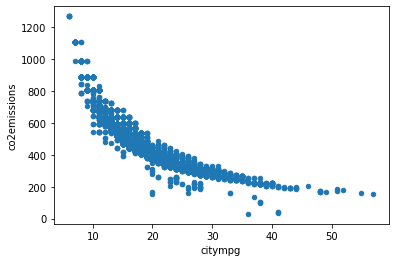

In [5]:
vehicles.plot(kind = "scatter", x = "citympg", y = "co2emissions")

According to this plot, the relationship between vehicle emission levels and city milage is negative. In other words, vehicles with higher milage emit less C02.

## How to create a Distribution Visualization

This type of visualisation shows the statistical distribution of the values of a feature (variable).

One of the most commonly used is the histogram. With histograms we can figure out which values are the most common for a feature.

<AxesSubplot:ylabel='Frequency'>

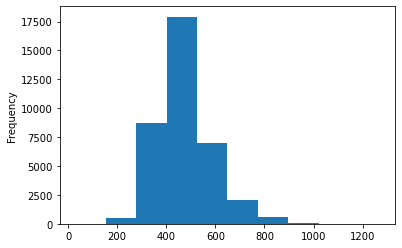

In [8]:
vehicles["co2emissions"].plot(kind = "hist")

The plot shows that the carbon emission values for the vehicles in the dataset, range from just under 200 Grams/Mile to just over 1000 Grams/Mile. It also shows that most of the vehicles fall roughtly within the 300 to the 700 Grams/Mile range.

## How to create a Comparision Visualization

Comparison Visualisation are used to illustrate the difference between two or more items at a given point in time or over a period of time.

One of the most commonly used is the box plot. With a box plot we can compare the distribution of values for a continuous feature against the value of categorical features.

IN order to create a box plot, we must first build a so called "pivot table" such that the value we want on the x axis of our plot, are listed as "column labels", while the value on the y axis are the cells values.

In [10]:
vehicles.pivot(columns = "drive", values = "co2emissions")

drive,2-Wheel Drive,4-Wheel Drive,All-Wheel Drive,Front-Wheel Drive,Rear-Wheel Drive
0,555.437500,NaN,NaN,NaN,NaN
1,555.437500,NaN,NaN,NaN,NaN
2,484.761905,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,424.166667
4,NaN,NaN,NaN,NaN,555.437500
...,...,...,...,...,...
36974,NaN,NaN,NaN,NaN,442.000000
36975,NaN,NaN,NaN,NaN,466.000000
36976,NaN,NaN,NaN,NaN,503.000000
36977,NaN,NaN,NaN,NaN,661.000000


<AxesSubplot:>

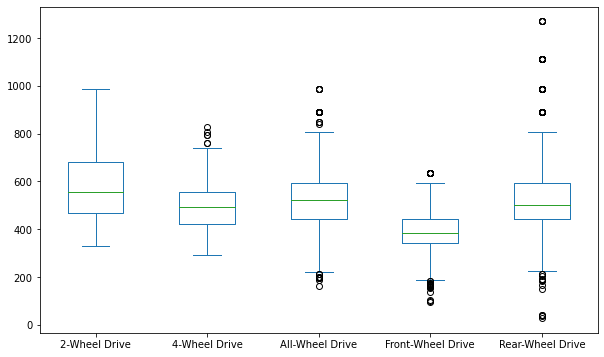

In [12]:
vehicles.pivot(columns = 'drive', values = 'co2emissions').plot(kind = "box",  figsize = (10,6))

From this box plot we can see that on average Front-Wheel drive cars have low carbon emission than other types of cars.

## How to create a Composition Visualization

This type of visualisation shows the component makeup of data.

Stacked bar charts are one of the most commonly used. Pie charts, along with stacked bar charts and grouped bar charts are three of the most commonly used composition visualizations.

It shows how much a subgroup contribute to the whole.

To create a stacked bar chart, we must first create a pivot table so that the values we want on the X axis of the plot are listed as "row-labels", while the composit groups are listed as "column labels".

To do this, we start with group-level aggregation.

In [14]:
vehicles.groupby("year")["drive"].value_counts()

year  drive            
1984  2-Wheel Drive        477
      All-Wheel Drive      301
      Rear-Wheel Drive       4
1985  Rear-Wheel Drive     772
      Front-Wheel Drive    672
                          ... 
2017  4-Wheel Drive        173
2018  All-Wheel Drive      245
      Rear-Wheel Drive     230
      Front-Wheel Drive    193
      4-Wheel Drive        124
Name: drive, Length: 123, dtype: int64

In [15]:
vehicles.groupby('year')['drive'].value_counts().unstack()

drive,2-Wheel Drive,4-Wheel Drive,All-Wheel Drive,Front-Wheel Drive,Rear-Wheel Drive
year,,,,,
1984,477.0,NaN,301.0,NaN,4.0
1985,NaN,NaN,255.0,672.0,772.0
1986,NaN,1.0,202.0,430.0,576.0
1987,NaN,NaN,220.0,470.0,557.0
1988,NaN,NaN,215.0,447.0,468.0
1989,NaN,NaN,227.0,445.0,480.0
1990,NaN,NaN,241.0,422.0,413.0
1991,NaN,NaN,243.0,431.0,456.0
1992,NaN,NaN,232.0,455.0,432.0


<AxesSubplot:xlabel='year'>

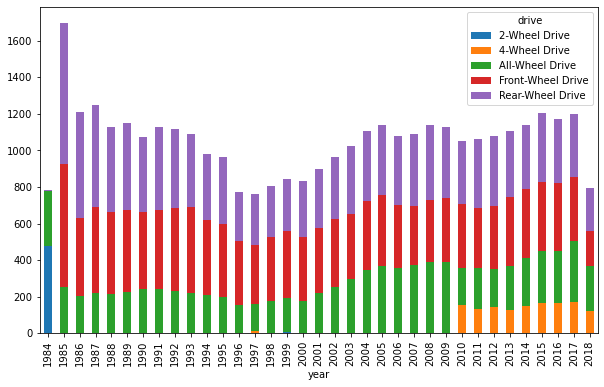

In [17]:
vehicles.groupby('year')['drive'].value_counts().unstack().plot(kind = "bar", stacked = True, figsize = (10,6))

The plot shows that the total number of vehicles for each year with a breakdown of the type of vehicles subgroup that makes the whole.